In [ ]:
import pandas as pd

# 1️⃣ 读取并预处理函数
def load_and_clean(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)

    # 时间戳统一到微秒
    df['Close Time'] = df['Close Time'].apply(lambda x: x * 1000 + 999 if x < 2000000000000 else x)
    df['Open Time']  = df['Open Time'] .apply(lambda x: x * 1000       if x < 2000000000000 else x)

    df['Close Time'] = pd.to_datetime(df['Close Time'], unit='us')
    df['Open Time']  = pd.to_datetime(df['Open Time'],  unit='us')
    return df.set_index("Close Time")

# 2️⃣ 逐个读入
btc  = load_and_clean("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/BTCUSDT_klines_5m.csv")
doge = load_and_clean("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/DOGEUSDT_klines_5m.csv")
xrp  = load_and_clean("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/XRPUSDT_klines_5m.csv")
pepe = load_and_clean("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/PEPEUSDT_klines_5m.csv")

# 3️⃣ 找共同 index（循环交集）
common_index = set(btc.index)
for df in [doge, xrp, pepe]:
    common_index = common_index & set(df.index)

common_index = sorted(common_index)  # 转回有序列表


btc.sort_index(inplace=True)
doge.sort_index(inplace=True)
xrp.sort_index(inplace=True)
pepe.sort_index(inplace=True)

btc.drop_duplicates(inplace=True)
doge.drop_duplicates(inplace=True)
xrp.drop_duplicates(inplace=True)
pepe.drop_duplicates(inplace=True)

In [2]:
df = btc

In [3]:
# 添加一列表示 index 所在的小时
df['Hour'] = df.index.hour
df['Day'] = df.index.date

# 添加一列表示 Close 相对于 144 行前的涨幅
df['Close_Change_12'] = (df['Close'].shift(-12)-df['Close']) / df['Close']
df['Close_Change_144'] = (df['Close'].shift(-144)-df['Close']) / df['Close']

df.head(20)

,index,Open Time,Open,High,Low,Close,Volume,Quote Asset Volume,Number of Trades,Taker Buy Base Volume,Taker Buy Quote Volume,Ignore,Hour,Day,Close_Change_12,Close_Change_144
Close Time,,,,,,,,,,,,,,,,
2024-09-01 00:04:59.999999,0,2024-09-01 00:00:00,58974.00,58978.00,58957.01,58978.00,15.92811,9.392461e+05,2237,5.84918,3.449034e+05,0,0,2024-09-01,-0.001000,-0.013456
2024-09-01 00:09:59.999999,1,2024-09-01 00:05:00,58978.00,59035.76,58975.41,59035.76,65.12076,3.841414e+06,2178,59.49265,3.509428e+06,0,0,2024-09-01,-0.001876,-0.013293
2024-09-01 00:14:59.999999,2,2024-09-01 00:10:00,59035.75,59055.00,59023.00,59038.12,25.99014,1.534441e+06,2407,9.34836,5.518978e+05,0,0,2024-09-01,-0.002738,-0.013570
2024-09-01 00:19:59.999999,3,2024-09-01 00:15:00,59038.11,59076.59,59024.00,59024.00,20.25307,1.195944e+06,2897,8.85072,5.226532e+05,0,0,2024-09-01,-0.001801,-0.014079
2024-09-01 00:24:59.999999,4,2024-09-01 00:20:00,59024.00,59024.00,58991.10,58991.10,18.29866,1.079629e+06,1939,12.31213,7.263588e+05,0,0,2024-09-01,-0.000968,-0.014578
2024-09-01 00:29:59.999999,5,2024-09-01 00:25:00,58991.11,58991.11,58911.00,58961.41,21.03756,1.240224e+06,2899,6.69470,3.946149e+05,0,0,2024-09-01,-0.000668,-0.015269
2024-09-01 00:34:59.999999,6,2024-09-01 00:30:00,58961.40,58961.41,58920.00,58949.99,16.50635,9.729498e+05,2880,8.20177,4.834285e+05,0,0,2024-09-01,-0.000848,-0.015134
2024-09-01 00:39:59.999999,7,2024-09-01 00:35:00,58950.00,58997.00,58949.99,58988.00,11.39609,6.721350e+05,2477,7.88792,4.651898e+05,0,0,2024-09-01,-0.002023,-0.016003
2024-09-01 00:44:59.999999,8,2024-09-01 00:40:00,58988.00,59019.00,58900.00,58908.99,23.31691,1.374968e+06,4333,8.15751,4.811113e+05,0,0,2024-09-01,-0.000441,-0.015906


In [4]:
hourly_stats = df.groupby('Hour').agg({
  'Close_Change_12': ['mean', 'std'],  # 计算 Close_Change_12 列的均值和标准差
  'Close_Change_144': ['mean', 'std']  # 计算 Close_Change_144 列的均值和标准差
})

In [ ]:
hourly_stats

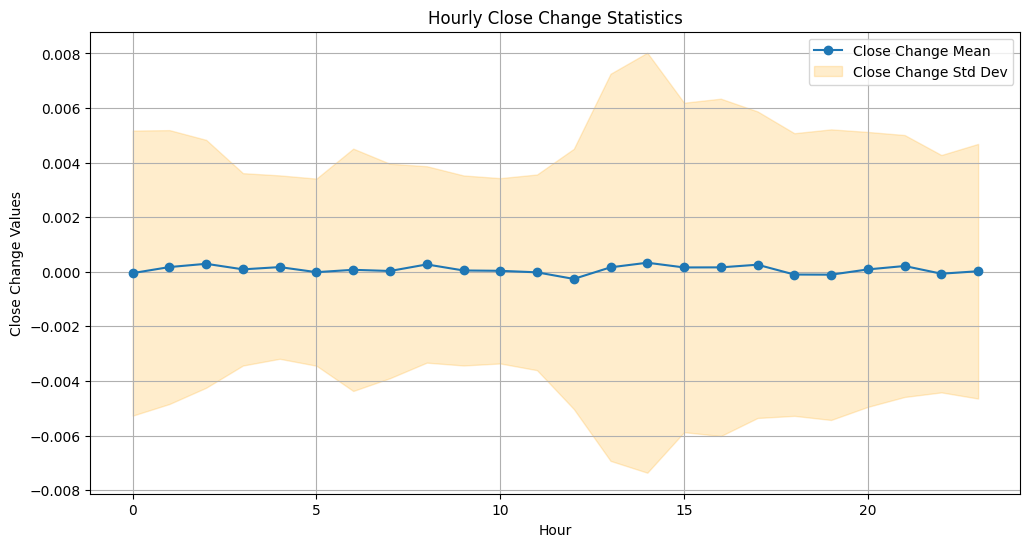

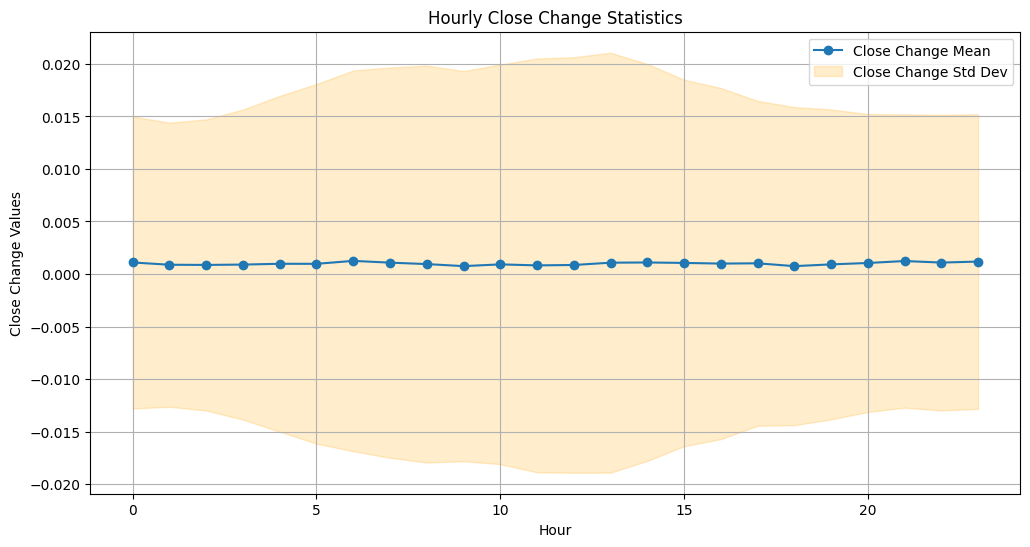

In [5]:
import matplotlib.pyplot as plt


# 绘制 Close_Change_12 的均值和标准差
plt.figure(figsize=(12, 6))
plt.plot(hourly_stats.index, hourly_stats[('Close_Change_12', 'mean')], label='Close Change Mean', marker='o')
plt.fill_between(hourly_stats.index, 
     hourly_stats[('Close_Change_12', 'mean')] - hourly_stats[('Close_Change_12', 'std')], 
     hourly_stats[('Close_Change_12', 'mean')] + hourly_stats[('Close_Change_12', 'std')], 
     color='orange', alpha=0.2, label='Close Change Std Dev')

# 添加图例和标签
plt.title('Hourly Close Change Statistics')
plt.xlabel('Hour')
plt.ylabel('Close Change Values')
plt.legend()
plt.grid()
plt.show()

# 绘制 Close_Change_144 的均值和标准差
plt.figure(figsize=(12, 6))
plt.plot(hourly_stats.index, hourly_stats[('Close_Change_144', 'mean')], label='Close Change Mean', marker='o')
plt.fill_between(hourly_stats.index, 
     hourly_stats[('Close_Change_144', 'mean')] - hourly_stats[('Close_Change_144', 'std')], 
     hourly_stats[('Close_Change_144', 'mean')] + hourly_stats[('Close_Change_144', 'std')], 
     color='orange', alpha=0.2, label='Close Change Std Dev')

# 添加图例和标签
plt.title('Hourly Close Change Statistics')
plt.xlabel('Hour')
plt.ylabel('Close Change Values')
plt.legend()
plt.grid()
plt.show()

In [6]:

# 打印结果
print(hourly_stats)

     Close_Change_12           Close_Change_144          
                mean       std             mean       std
Hour                                                     
0          -0.000049  0.005222         0.001100  0.013890
1           0.000173  0.005017         0.000884  0.013519
2           0.000293  0.004540         0.000866  0.013849
3           0.000089  0.003524         0.000899  0.014752
4           0.000172  0.003360         0.000975  0.015975
5          -0.000014  0.003428         0.000971  0.017111
6           0.000072  0.004439         0.001252  0.018116
7           0.000029  0.003927         0.001083  0.018569
8           0.000269  0.003598         0.000947  0.018885
9           0.000048  0.003481         0.000752  0.018562
10          0.000036  0.003395         0.000919  0.019009
11         -0.000020  0.003585         0.000822  0.019688
12         -0.000261  0.004766         0.000861  0.019768
13          0.000163  0.007091         0.001079  0.019979
14          0.

In [7]:
df_byday_byhour = df.groupby(['Day', 'Hour']).agg({
  'Close_Change_12': ['mean'],  # 计算 Close_Change_12 列的均值和标准差
  'Close_Change_144': ['mean']  # 计算 Close_Change_144 列的均值和标准差
})

In [8]:
# 根据 Hour 分成 24 个表
hourly_dfs = {hour: df_byday_byhour.xs(hour, level='Hour') for hour in range(24)}

# 示例：访问某个小时的表，例如 0 点
hourly_dfs[0]

,Close_Change_12,Close_Change_144
,mean,mean
Day,,
2024-09-01,-0.001362,-0.015001
2024-09-02,-0.000377,0.016435
2024-09-03,0.002428,0.001147
2024-09-04,-0.022257,-0.019325
2024-09-05,-0.000619,-0.025868
...,...,...
2025-08-27,-0.003066,-0.003461
2025-08-28,0.002639,0.015788


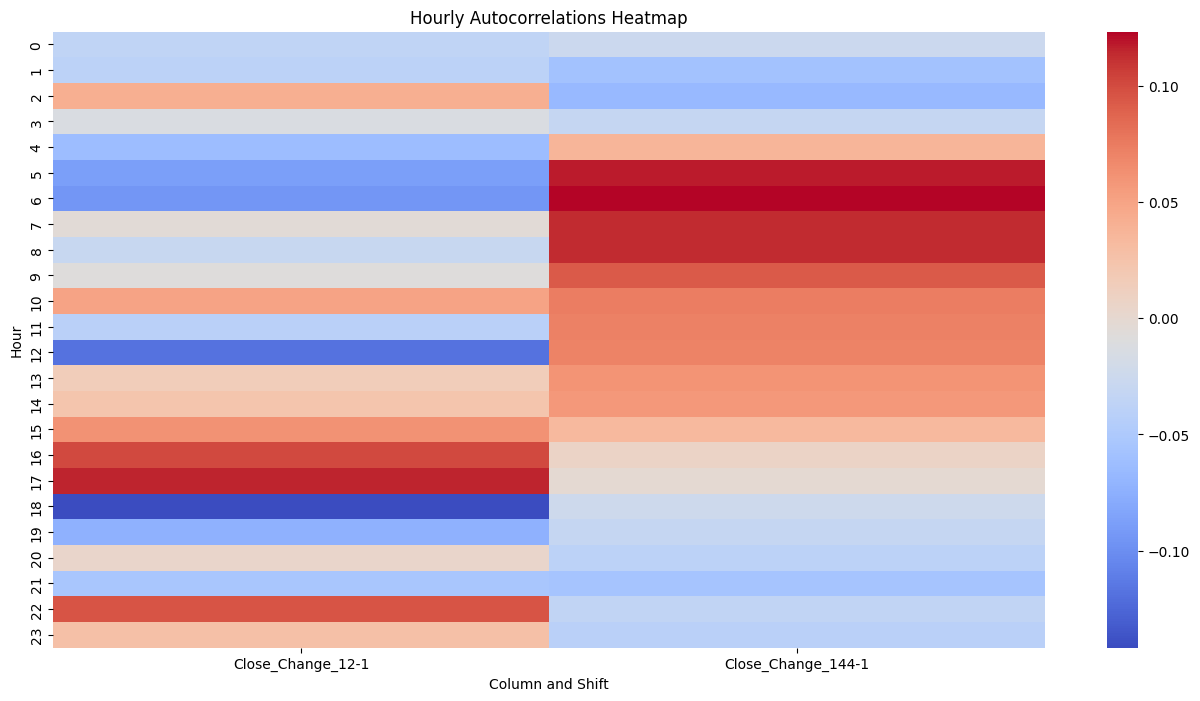

In [9]:
autocorrelations = {}

for hour, df in hourly_dfs.items():
  autocorrelations[hour] = {}
  for col in ['Close_Change_12', 'Close_Change_144']:
    col_mean = df[(col, 'mean')]
    autocorrelations[hour][col] = [col_mean.corr(col_mean.shift(shift)) for shift in range(1, 8)]
    
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt

# 将 autocorrelations 转换为适合绘图的 DataFrame
autocorr_df = pd.DataFrame({
  (col, shift): [autocorrelations[hour][col][shift] for hour in range(24)]
  for col in ['Close_Change_12', 'Close_Change_144']
  for shift in range(1,2)
}, index=range(24))

# 绘制热力图
plt.figure(figsize=(16, 8))
sns.heatmap(autocorr_df, annot=False, cmap='coolwarm', cbar=True, xticklabels=True, yticklabels=True)
plt.title('Hourly Autocorrelations Heatmap')
plt.xlabel('Column and Shift')
plt.ylabel('Hour')
plt.show()

Day
2024-09-01    0.003755
2024-09-02    0.012721
2024-09-03   -0.018323
2024-09-04    0.025236
2024-09-05   -0.005688
                ...   
2025-08-27    0.010132
2025-08-28   -0.004601
2025-08-29   -0.026174
2025-08-30    0.003804
2025-08-31    0.003634
Name: (Close_Change_144, mean), Length: 365, dtype: float64
Day
2024-09-01         NaN
2024-09-02    0.003755
2024-09-03    0.012721
2024-09-04   -0.018323
2024-09-05    0.025236
                ...   
2025-08-27    0.003464
2025-08-28    0.010132
2025-08-29   -0.004601
2025-08-30   -0.026174
2025-08-31    0.003804
Name: (Close_Change_144, mean), Length: 365, dtype: float64


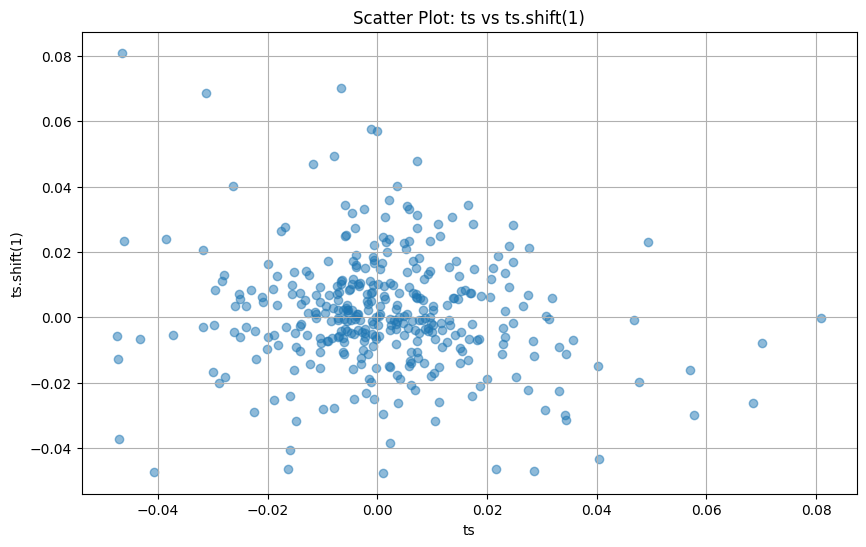

In [10]:
ts = hourly_dfs[6]['Close_Change_144', 'mean']
print(ts)
print(ts.shift(1))
import matplotlib.pyplot as plt

# 假设 ts 是一个 pandas Series
plt.figure(figsize=(10, 6))
plt.scatter(ts, ts.shift(1), alpha=0.5)
plt.title('Scatter Plot: ts vs ts.shift(1)')
plt.xlabel('ts')
plt.ylabel('ts.shift(1)')
plt.grid()
plt.show()

In [15]:
def simp_strat(ts, thres):
  results = []
  for th in thres:
    result = []
    value = 0
    count = 0
    for time in ts.index:
      change = ts.loc[time]
      if change < -th and time + pd.Timedelta(days=1) in ts.index:
        value += ts.loc[time + pd.Timedelta(days=1)]
        count += 1
      result.append(value)
    results.append(result)
    print(f"thres={th}, final value={value}, trades={count}, avg per trade={value/count if count>0 else 0}")
  return results

thres = [0.005, 0.010, 0.015, 0.02, 0.025]
rsts = simp_strat(hourly_dfs[6]['Close_Change_144', 'mean'], thres)

thres=0.005, final value=0.4088022652837934, trades=121, avg per trade=0.0033785311180478794
thres=0.01, final value=0.40609180859942495, trades=77, avg per trade=0.005273919592200324
thres=0.015, final value=0.3506960314977169, trades=53, avg per trade=0.006616906254673903
thres=0.02, final value=0.21003833226667068, trades=34, avg per trade=0.006177598007843255
thres=0.025, final value=0.1471594832140513, trades=25, avg per trade=0.005886379328562052


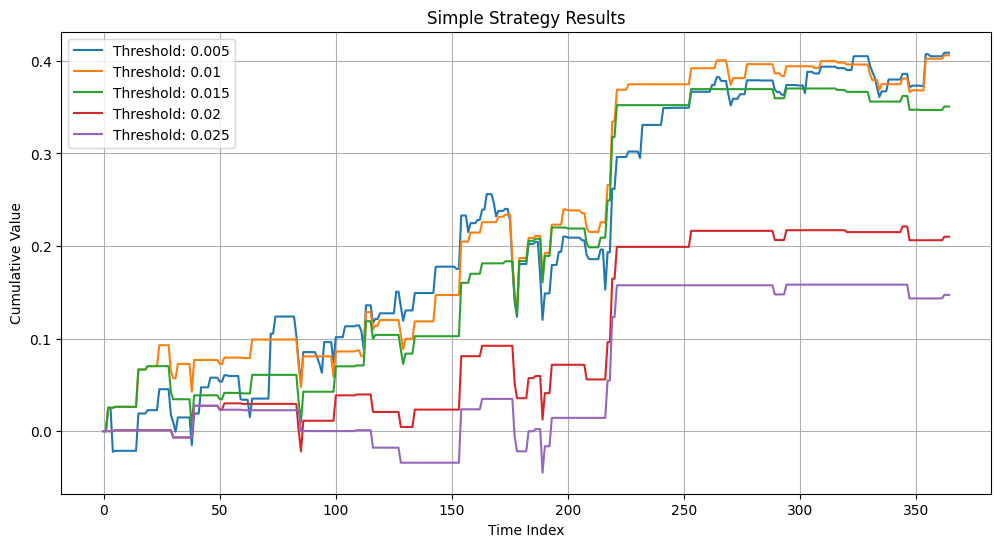

In [16]:

# 可视化结果
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for i, th in enumerate(thres):
  plt.plot(rsts[i], label=f'Threshold: {th}')
plt.title('Simple Strategy Results')
plt.xlabel('Time Index')
plt.ylabel('Cumulative Value')
plt.legend()
plt.grid()
plt.show()